
# Citi Bike - Follow-On Experiments Based on v7

This notebook is a **new follow-on experiments notebook** for the capacity-aware **v7** workflow.

It is built around the key v7 change:
- the project is now **availability-first**,
- the main target is **`utilization_ratio_next_hour`**,
- and the most important question is whether the new **availability-state features** are driving the gain.

## What this notebook does

1. Load the **v7 feature parquet**.
2. Benchmark the new availability target against the older demand / flow targets.
3. Run **top-N sensitivity** on the new target.
4. Run **feature ablations** centered on availability-state variables.
5. Compare **all usable rows** vs **capacity-known-only rows**.
6. Run **operational alert tasks** for nearly-empty / nearly-full stations.
7. Optionally inspect **feature importance** and save result tables.

## Expected input

This notebook expects a parquet like:
- `feature_df_model_ready_2025_v7_final.parquet`, or
- `feature_df_model_ready_2025_v7.parquet`

The feature dataframe should already contain the v7 engineered columns, including the availability-style fields such as:
- `capacity`
- `capacity_known`
- `capacity_imputed`
- `estimated_bikes_*`
- `available_docks_*`
- `utilization_ratio_*`


In [2]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not running in Colab or already mounted).')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)



## Configuration

Adjust these paths or settings if your environment is different.


In [4]:

FEATURE_CACHE_CANDIDATES = [
    Path('outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('outputs/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7.parquet'),
]

OUTPUT_DIR_CANDIDATES = [
    Path('outputs'),
    Path('/content/outputs'),
    Path('/mnt/data/outputs'),
]

RUN_HEAVY_EXPERIMENTS = True
SAVE_OUTPUT_TABLES = True
PRIMARY_TARGET = 'utilization_ratio_next_hour'
TARGET_COMPARISON = [
    'utilization_ratio_next_hour',
    'net_flow_next_hour',
    'departures_next_hour',
    'arrivals_next_hour',
]
DEFAULT_TOP_N_STATIONS = 150
TOP_N_GRID = [50, 150, 300]
MAX_ROWS_PER_EXPERIMENT = 350_000
RANDOM_STATE = 42

print('Primary target:', PRIMARY_TARGET)
print('Top-N grid:', TOP_N_GRID)
print('Heavy experiments enabled:', RUN_HEAVY_EXPERIMENTS)


Primary target: utilization_ratio_next_hour
Top-N grid: [50, 150, 300]
Heavy experiments enabled: True



## Optional: copy the v7 parquet from Drive into the runtime

Run this only if your runtime cannot see the parquet directly but Drive has the file.


In [5]:

# Example:
# import shutil
# src = '/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'
# dst = '/content/feature_df_model_ready_2025_v7_final.parquet'
# shutil.copy2(src, dst)
# print('Copied to:', dst)


## Load the v7 feature dataframe

In [6]:

def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


def resolve_output_dir(candidates):
    for path in candidates:
        try:
            path.mkdir(parents=True, exist_ok=True)
            return path
        except Exception:
            continue
    return None


FEATURE_CACHE = locate_existing_path(FEATURE_CACHE_CANDIDATES)
OUTPUT_DIR = resolve_output_dir(OUTPUT_DIR_CANDIDATES)

print('Resolved feature cache:', FEATURE_CACHE)
print('Resolved output dir:', OUTPUT_DIR)

if FEATURE_CACHE is None:
    raise FileNotFoundError(
        'Could not find a v7 feature parquet. Update FEATURE_CACHE_CANDIDATES or copy the parquet into the runtime.'
    )

try:
    size = FEATURE_CACHE.stat().st_size
    with open(FEATURE_CACHE, 'rb') as f:
        head = f.read(4)
        f.seek(-4, 2)
        tail = f.read(4)
    print(f'Parquet integrity check -> size={size:,} head={head} tail={tail}')
except Exception as e:
    print('Parquet integrity check failed:', e)

feature_df = pd.read_parquet(FEATURE_CACHE)

if 'station_key' in feature_df.columns:
    feature_df['station_key'] = feature_df['station_key'].astype('category')
if 'station_cluster' in feature_df.columns:
    feature_df['station_cluster'] = feature_df['station_cluster'].astype('category')
if 'hour' in feature_df.columns:
    feature_df['hour'] = pd.to_datetime(feature_df['hour'])

print('Loaded shape:', feature_df.shape)
display(feature_df.head())


Resolved feature cache: /content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet
Resolved output dir: outputs
Parquet integrity check -> size=819,677,632 head=b'PAR1' tail=b'PAR1'
Loaded shape: (11966828, 97)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_id,station_name,lat,lng,station_name_norm,gbfs_name,capacity_raw,capacity_known,capacity_imputed,is_active_station,capacity,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,estimated_bikes,available_docks,utilization_ratio,is_nearly_empty,is_nearly_full,estimated_bikes_lag_1,estimated_bikes_lag_2,estimated_bikes_lag_24,estimated_bikes_roll_3,estimated_bikes_roll_24,available_docks_lag_1,available_docks_lag_2,available_docks_lag_24,available_docks_roll_3,available_docks_roll_24,utilization_ratio_lag_1,utilization_ratio_lag_2,utilization_ratio_lag_24,utilization_ratio_roll_3,utilization_ratio_roll_24,estimated_bikes_next_hour,available_docks_next_hour,utilization_ratio_next_hour,station_cluster,weather_pc_1,weather_pc_2,weather_pc_3
0,1234.56,2025-06-18 22:00:00,0,1,1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,13.0,11.0,0.541667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,11.0,0.541667,2,2.757381,-0.368786,-1.766357
1,1234.56,2025-06-18 23:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0,13.0,11.0,0.541667,0,0,13.0,NaN,NaN,13.000000,13.000000,11.0,NaN,NaN,11.000000,11.000000,0.541667,NaN,NaN,0.541667,0.541667,11.0,13.0,0.458333,2,2.690833,-0.238696,-1.318855
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0,11.0,13.0,0.458333,0,0,13.0,13.0,NaN,13.000000,13.000000,11.0,11.0,NaN,11.000000,11.000000,0.541667,0.541667,NaN,0.541667,0.541667,12.0,12.0,0.500000,2,1.421356,0.119499,1.292002
3,1234.56,2025-06-20 09:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0,12.0,12.0,0.500000,0,0,11.0,13.0,NaN,12.333333,12.333333,13.0,11.0,NaN,11.666667,11.666667,0.458333,0.541667,NaN,0.513889,0.513889,12.0,12.0,0.500000,2,0.488080,-0.150773,2.193309
4,1234.56,2025-06-20 12:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,

## Quick sanity checks

,column,non_null_rate,dtype
0,station_key,1.000000,category
1,hour,1.000000,datetime64[ns]
2,departures,1.000000,int32
3,arrivals,1.000000,int32
4,net_flow,1.000000,int32
5,total_activity,1.000000,int32
6,station_id,1.000000,string
7,station_name,1.000000,string
8,lat,1.000000,string
9,lng,1.000000,string


,count,mean,std,min,25%,50%,75%,max
capacity,11966828.0,35.013214,19.150441,0.0,21.000000,27.0,43.000000,123.0
capacity_raw,11829473.0,35.141091,19.224282,0.0,21.000000,27.0,43.000000,123.0
capacity_known,11966828.0,0.988522,0.106519,0.0,1.000000,1.0,1.000000,1.0
capacity_imputed,11966828.0,0.011478,0.106519,0.0,0.000000,0.0,0.000000,1.0
estimated_bikes,11955321.0,17.058826,13.602242,0.0,9.000000,13.0,21.500000,123.0
available_docks,11955321.0,17.988117,12.835156,0.0,10.500000,14.5,22.500000,123.0
utilization_ratio,11955321.0,0.476879,0.218159,0.0,0.369565,0.5,0.586957,1.0
utilization_ratio_next_hour,11952895.0,0.476874,0.218179,0.0,0.369565,0.5,0.586957,1.0
is_nearly_empty,11966828.0,0.071982,0.258458,0.0,0.000000,0.0,0.000000,1.0
is_nearly_full,11966828.0,0.048334,0.214471,0.0,0.000000,0.0,0.000000,1.0


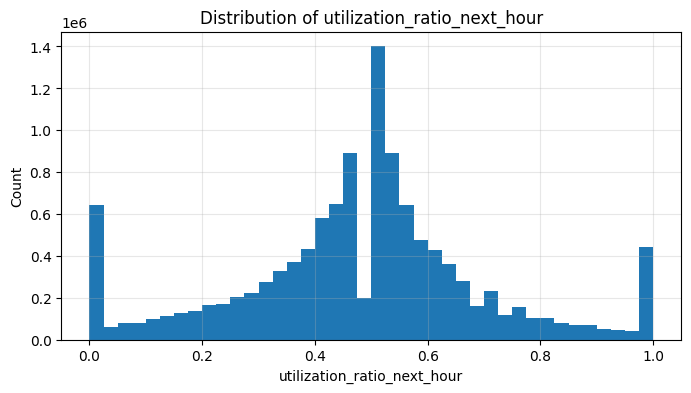

In [7]:

coverage = pd.DataFrame({
    'column': feature_df.columns,
    'non_null_rate': [feature_df[c].notna().mean() for c in feature_df.columns],
    'dtype': [str(feature_df[c].dtype) for c in feature_df.columns],
}).sort_values('non_null_rate', ascending=False)

display(coverage.head(50))

focus_cols = [
    c for c in [
        'capacity', 'capacity_raw', 'capacity_known', 'capacity_imputed',
        'estimated_bikes', 'available_docks', 'utilization_ratio',
        'utilization_ratio_next_hour', 'is_nearly_empty', 'is_nearly_full'
    ] if c in feature_df.columns
]

if focus_cols:
    display(feature_df[focus_cols].describe(include='all').T)

if 'utilization_ratio_next_hour' in feature_df.columns:
    plt.figure(figsize=(8, 4))
    feature_df['utilization_ratio_next_hour'].dropna().clip(0, 1).hist(bins=40)
    plt.title('Distribution of utilization_ratio_next_hour')
    plt.xlabel('utilization_ratio_next_hour')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.show()



## Helpers and feature groups

These helpers mirror the v7 modeling assumptions:
- keep the split chronological,
- use dense preprocessing for mixed numeric / categorical tabular data,
- evaluate both linear and random-forest baselines,
- and center ablations on the new availability-state variables.


In [8]:

def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)


FEATURE_GROUPS = {
    'calendar': [
        'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
        'is_rush_hour', 'is_commute_peak', 'is_overnight',
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
    ],
    'weather': [
        'is_precipitating', 'is_raining', 'is_snowing', 'heavy_precip_flag'
    ],
    'raw_flow_state': [
        'departures_lag_1', 'departures_lag_2', 'departures_lag_24',
        'arrivals_lag_1', 'arrivals_lag_2', 'arrivals_lag_24',
        'net_flow_lag_1', 'net_flow_lag_2', 'net_flow_lag_24',
        'total_activity_lag_1', 'total_activity_lag_2', 'total_activity_lag_24',
        'departures_roll_3', 'departures_roll_24',
        'arrivals_roll_3', 'arrivals_roll_24',
        'net_flow_roll_3', 'net_flow_roll_24',
        'total_activity_roll_3', 'total_activity_roll_24',
    ],
    'availability_state': [
        'capacity', 'capacity_known', 'capacity_imputed', 'is_active_station',
        'estimated_bikes_lag_1', 'estimated_bikes_lag_2', 'estimated_bikes_lag_24',
        'estimated_bikes_roll_3', 'estimated_bikes_roll_24',
        'available_docks_lag_1', 'available_docks_lag_2', 'available_docks_lag_24',
        'available_docks_roll_3', 'available_docks_roll_24',
        'utilization_ratio_lag_1', 'utilization_ratio_lag_2', 'utilization_ratio_lag_24',
        'utilization_ratio_roll_3', 'utilization_ratio_roll_24',
        'is_nearly_empty', 'is_nearly_full',
    ],
    'spatial_station': ['station_key', 'station_cluster', 'lat', 'lng'],
}
FEATURE_GROUPS['weather_pca'] = []


def add_weather_pca_features(df):
    return [c for c in df.columns if c.startswith('weather_pc_')]


def available_features(df, cols):
    return [c for c in cols if c in df.columns]


def busiest_station_keys(df, top_n=150):
    activity_col = 'total_activity' if 'total_activity' in df.columns else 'departures'
    return (
        df.groupby('station_key', observed=True)[activity_col]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )


def chronological_split(model_df):
    model_df = model_df.sort_values('hour').reset_index(drop=True)
    unique_hours = np.sort(model_df['hour'].dropna().unique())
    if len(unique_hours) < 10:
        raise ValueError('Not enough hourly periods for a 70/15/15 chronological split.')

    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df['hour'] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df['hour'] >= train_cutoff) & (model_df['hour'] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df['hour'] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


def safe_roc_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


class DenseTabularPreprocessor:
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.num_imputer = SimpleImputer(strategy='median') if self.numeric_features else None
        self.cat_imputer = SimpleImputer(strategy='most_frequent') if self.categorical_features else None
        self.onehot = make_dense_onehot_encoder() if self.categorical_features else None
        self.feature_names_out_ = None

    def fit(self, X):
        feature_names = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            self.num_imputer.fit(num_df)
            feature_names.extend(self.numeric_features)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.fit_transform(cat_df)
            self.onehot.fit(cat_filled)
            feature_names.extend(self.onehot.get_feature_names_out(self.categorical_features).tolist())

        self.feature_names_out_ = np.asarray(feature_names, dtype=object)
        return self

    def transform(self, X):
        parts = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            num_arr = self.num_imputer.transform(num_df).astype(np.float32, copy=False)
            parts.append(num_arr)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.transform(cat_df)
            cat_arr = self.onehot.transform(cat_filled).astype(np.float32, copy=False)
            parts.append(cat_arr)

        if not parts:
            return np.empty((len(X), 0), dtype=np.float32)
        return np.concatenate(parts, axis=1).astype(np.float32, copy=False)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def prepare_xy(train_df, valid_df, test_df, feature_cols, target_col):
    categorical = [
        c for c in feature_cols
        if str(train_df[c].dtype) in {'category', 'string'} or c in {'station_key', 'station_cluster'}
    ]
    categorical = [c for c in categorical if c in feature_cols]
    numeric = [c for c in feature_cols if c not in categorical]

    prep = DenseTabularPreprocessor(numeric_features=numeric, categorical_features=categorical)
    X_train = prep.fit_transform(train_df[feature_cols])
    X_valid = prep.transform(valid_df[feature_cols])
    X_test = prep.transform(test_df[feature_cols])

    y_train = pd.to_numeric(train_df[target_col], errors='coerce').to_numpy()
    y_valid = pd.to_numeric(valid_df[target_col], errors='coerce').to_numpy()
    y_test = pd.to_numeric(test_df[target_col], errors='coerce').to_numpy()
    return prep, X_train, X_valid, X_test, y_train, y_valid, y_test


def maybe_downsample(df, max_rows=MAX_ROWS_PER_EXPERIMENT):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    return df.sample(max_rows, random_state=RANDOM_STATE).sort_values('hour').reset_index(drop=True)


def build_model_df(df, target_col, feature_cols, top_n=DEFAULT_TOP_N_STATIONS, require_capacity_known=False):
    busy = busiest_station_keys(df, top_n=top_n)
    keep_cols = ['hour', target_col] + [c for c in feature_cols if c in df.columns]

    base_mask = df['station_key'].isin(busy)
    if require_capacity_known and 'capacity_known' in df.columns:
        base_mask = base_mask & (pd.to_numeric(df['capacity_known'], errors='coerce') == 1)

    model_df = df.loc[base_mask, keep_cols].copy()
    model_df = model_df.loc[model_df[target_col].notna()].copy()

    for col in ['station_key', 'station_cluster']:
        if col in model_df.columns:
            model_df[col] = model_df[col].astype('category')

    return maybe_downsample(model_df)


def fit_regression_suite(train_df, valid_df, test_df, feature_cols, target_col):
    prep, X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_xy(
        train_df, valid_df, test_df, feature_cols, target_col
    )

    baseline_value = float(np.nanmean(y_train))
    valid_baseline = np.repeat(baseline_value, len(y_valid))
    test_baseline = np.repeat(baseline_value, len(y_test))

    models = {
        'Naive mean': None,
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1),
        'Random Forest (deeper)': RandomForestRegressor(
            n_estimators=220,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    rows = []
    artifacts = {}

    rows.append({
        'model': 'Naive mean',
        'split': 'validation',
        **regression_metrics(y_valid, valid_baseline),
    })
    rows.append({
        'model': 'Naive mean',
        'split': 'test',
        **regression_metrics(y_test, test_baseline),
    })

    for name, model in models.items():
        if model is None:
            continue
        model.fit(X_train, y_train)
        valid_pred = model.predict(X_valid)
        test_pred = model.predict(X_test)

        rows.append({'model': name, 'split': 'validation', **regression_metrics(y_valid, valid_pred)})
        rows.append({'model': name, 'split': 'test', **regression_metrics(y_test, test_pred)})
        artifacts[name] = {
            'model': model,
            'preprocessor': prep,
            'feature_names': prep.feature_names_out_,
            'valid_pred': valid_pred,
            'test_pred': test_pred,
            'y_valid': y_valid,
            'y_test': y_test,
            'test_df': test_df.copy(),
        }

    return pd.DataFrame(rows), artifacts


def top_feature_importance(trained_artifacts, model_name='Random Forest (deeper)', top_k=20):
    artifact = trained_artifacts.get(model_name)
    if artifact is None:
        return None
    model = artifact['model']
    if not hasattr(model, 'feature_importances_'):
        return None
    out = pd.DataFrame({
        'feature': artifact['feature_names'],
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    return out.head(top_k)


FEATURE_GROUPS['weather_pca'] = add_weather_pca_features(feature_df)

CORE_ALL = list(dict.fromkeys(
    FEATURE_GROUPS['calendar']
    + FEATURE_GROUPS['weather']
    + FEATURE_GROUPS['weather_pca']
    + FEATURE_GROUPS['raw_flow_state']
    + FEATURE_GROUPS['availability_state']
    + FEATURE_GROUPS['spatial_station']
))

ABLATION_SETS = {
    'All v7 features': available_features(feature_df, CORE_ALL),
    'No availability-state features': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['weather'] + FEATURE_GROUPS['weather_pca']
        + FEATURE_GROUPS['raw_flow_state'] + FEATURE_GROUPS['spatial_station']
    ),
    'Availability-state + calendar only': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['availability_state'] + FEATURE_GROUPS['spatial_station']
    ),
    'Raw-flow + calendar only': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['raw_flow_state'] + FEATURE_GROUPS['spatial_station']
    ),
}

for name, cols in ABLATION_SETS.items():
    print(f'{name:34} -> {len(cols)} features')


All v7 features                    -> 64 features
No availability-state features     -> 43 features
Availability-state + calendar only -> 37 features
Raw-flow + calendar only           -> 36 features



## Experiment 1 - show why the target changed

This compares the new availability target against the older targets using the same general modeling pipeline.

Interpretation note:
- RMSE values are not directly comparable across different targets because the scales differ.
- **R²** is the more useful comparison here.


,target,selected_model,validation_r2,test_r2,test_rmse,rows_used
0,utilization_ratio_next_hour,Random Forest,0.840162,0.835604,0.100000,350000
3,arrivals_next_hour,Random Forest,0.761820,0.658738,4.684271,350000
2,departures_next_hour,Random Forest,0.765494,0.646004,4.653555,350000
1,net_flow_next_hour,Random Forest,0.476302,0.376639,4.583276,350000


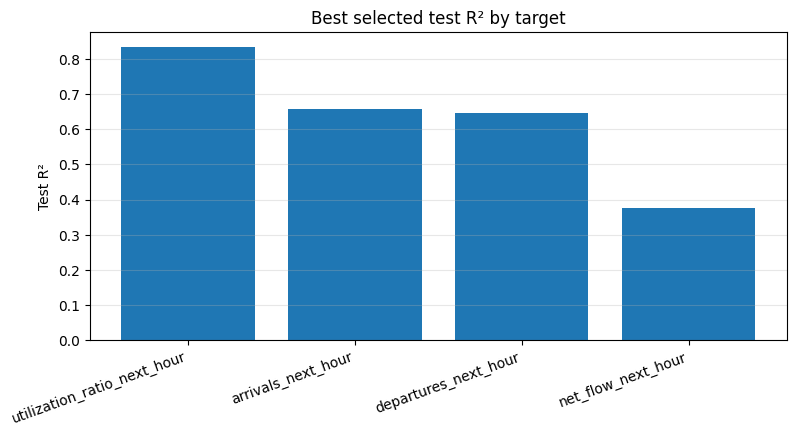

In [ ]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    comparison_rows = []
    comparison_artifacts = {}

    for target_col in TARGET_COMPARISON:
        if target_col not in feature_df.columns:
            print('Skipping missing target:', target_col)
            continue

        model_df = build_model_df(
            feature_df,
            target_col,
            ABLATION_SETS['All v7 features'],
            top_n=DEFAULT_TOP_N_STATIONS,
        )
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(
            train_df, valid_df, test_df, ABLATION_SETS['All v7 features'], target_col
        )

        best_valid = metrics_df.loc[metrics_df['split'] == 'validation'].sort_values('r2', ascending=False).iloc[0]
        best_test = metrics_df.loc[
            (metrics_df['split'] == 'test') & (metrics_df['model'] == best_valid['model'])
        ].iloc[0]

        comparison_rows.append({
            'target': target_col,
            'selected_model': best_valid['model'],
            'validation_r2': best_valid['r2'],
            'test_r2': best_test['r2'],
            'test_rmse': best_test['rmse'],
            'rows_used': len(model_df),
        })
        comparison_artifacts[target_col] = {'metrics_df': metrics_df, 'artifacts': artifacts}

    target_comparison_results = pd.DataFrame(comparison_rows).sort_values('test_r2', ascending=False)
    display(target_comparison_results)

    if not target_comparison_results.empty:
        plt.figure(figsize=(9, 4))
        plt.bar(target_comparison_results['target'], target_comparison_results['test_r2'])
        plt.title('Best selected test R² by target')
        plt.ylabel('Test R²')
        plt.xticks(rotation=20, ha='right')
        plt.grid(True, axis='y', alpha=0.3)
        plt.show()



## Experiment 2 - top-N station sensitivity for the availability target

This tests whether `utilization_ratio_next_hour` remains strong as you widen the station set beyond the busiest subset.


,model,split,rmse,mae,r2,selected_model,top_n_stations,rows_used
0,Random Forest,test,0.097441,0.067018,0.844048,Random Forest,50,350000
1,Random Forest,test,0.100000,0.068509,0.835604,Random Forest,150,350000
2,Random Forest,test,0.097468,0.067393,0.830743,Random Forest,300,350000


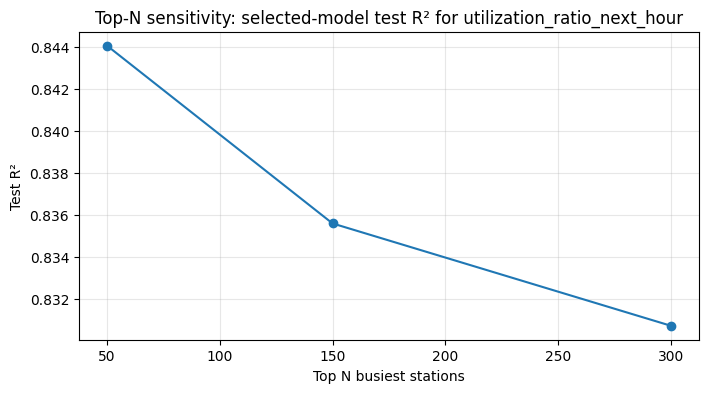

In [ ]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    topn_rows = []
    topn_artifacts = {}

    for top_n in TOP_N_GRID:
        model_df = build_model_df(feature_df, PRIMARY_TARGET, ABLATION_SETS['All v7 features'], top_n=top_n)
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, ABLATION_SETS['All v7 features'], PRIMARY_TARGET)

        best_valid = metrics_df.loc[metrics_df['split'] == 'validation'].sort_values('r2', ascending=False).iloc[0]
        best_test = metrics_df.loc[
            (metrics_df['split'] == 'test') & (metrics_df['model'] == best_valid['model'])
        ].iloc[0].to_dict()
        best_test['selected_model'] = best_valid['model']
        best_test['top_n_stations'] = top_n
        best_test['rows_used'] = len(model_df)
        topn_rows.append(best_test)
        topn_artifacts[top_n] = {'metrics_df': metrics_df, 'artifacts': artifacts}

    topn_results = pd.DataFrame(topn_rows).sort_values('top_n_stations')
    display(topn_results)

    if not topn_results.empty:
        plt.figure(figsize=(8, 4))
        plt.plot(topn_results['top_n_stations'], topn_results['r2'], marker='o')
        plt.title('Top-N sensitivity: selected-model test R² for utilization_ratio_next_hour')
        plt.xlabel('Top N busiest stations')
        plt.ylabel('Test R²')
        plt.grid(True, alpha=0.3)
        plt.show()



## Experiment 3 - feature ablation around availability state

This is the most important follow-on experiment after v7.
It checks whether the gain is really coming from the new capacity-aware station-state variables.


,model,split,rmse,mae,r2,selected_model,experiment,feature_count,rows_used
0,Random Forest,test,0.100000,0.068509,0.835604,Random Forest,All v7 features,64,350000
2,Random Forest,test,0.103822,0.071696,0.822796,Random Forest,Availability-state + calendar only,37,350000
3,Random Forest,test,0.148007,0.106752,0.639874,Random Forest,Raw-flow + calendar only,36,350000
1,Random Forest,test,0.148339,0.107139,0.638253,Random Forest,No availability-state features,43,350000


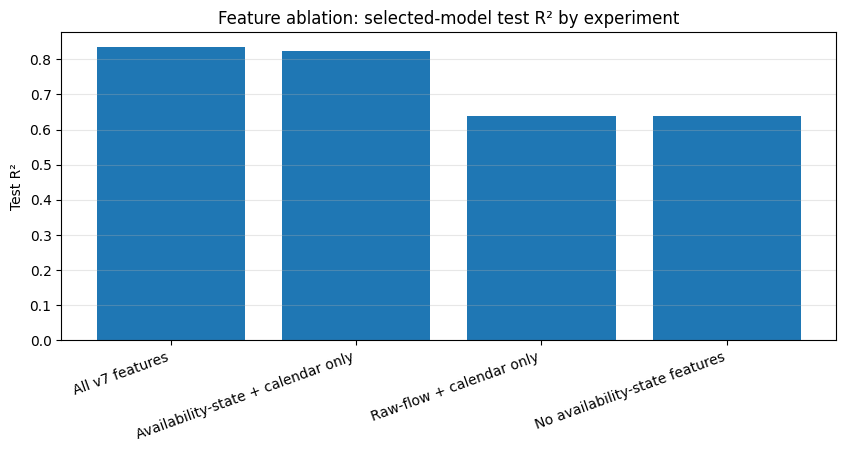

In [9]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    ablation_rows = []
    ablation_artifacts = {}

    for label, cols in ABLATION_SETS.items():
        model_df = build_model_df(feature_df, PRIMARY_TARGET, cols, top_n=DEFAULT_TOP_N_STATIONS)
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, cols, PRIMARY_TARGET)

        best_valid = metrics_df.loc[metrics_df['split'] == 'validation'].sort_values('r2', ascending=False).iloc[0]
        best_test = metrics_df.loc[
            (metrics_df['split'] == 'test') & (metrics_df['model'] == best_valid['model'])
        ].iloc[0].to_dict()
        best_test['selected_model'] = best_valid['model']
        best_test['experiment'] = label
        best_test['feature_count'] = len(cols)
        best_test['rows_used'] = len(model_df)
        ablation_rows.append(best_test)
        ablation_artifacts[label] = {'metrics_df': metrics_df, 'artifacts': artifacts}

    ablation_results = pd.DataFrame(ablation_rows).sort_values('r2', ascending=False)
    display(ablation_results)

    if not ablation_results.empty:
        plt.figure(figsize=(10, 4))
        plt.bar(ablation_results['experiment'], ablation_results['r2'])
        plt.title('Feature ablation: selected-model test R² by experiment')
        plt.ylabel('Test R²')
        plt.xticks(rotation=20, ha='right')
        plt.grid(True, axis='y', alpha=0.3)
        plt.show()



## Experiment 4 - all usable rows vs capacity-known rows only

This checks whether results are sensitive to the capacity merge. If the two rows are close,
that supports the v7 claim that the capacity-aware target is robust enough to use as the main project direction.


In [10]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    subset_rows = []
    subset_defs = [
        ('All usable rows', False),
        ('Capacity-known rows only', True),
    ]

    subset_features = ABLATION_SETS['All v7 features']

    for label, require_known in subset_defs:
        model_df = build_model_df(
            feature_df,
            PRIMARY_TARGET,
            subset_features,
            top_n=DEFAULT_TOP_N_STATIONS,
            require_capacity_known=require_known,
        )
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, subset_features, PRIMARY_TARGET)

        best_valid = metrics_df.loc[metrics_df['split'] == 'validation'].sort_values('r2', ascending=False).iloc[0]
        best_test = metrics_df.loc[
            (metrics_df['split'] == 'test') & (metrics_df['model'] == best_valid['model'])
        ].iloc[0].to_dict()
        best_test['selected_model'] = best_valid['model']
        best_test['subset'] = label
        best_test['rows_used'] = len(model_df)
        subset_rows.append(best_test)

    subset_results = pd.DataFrame(subset_rows).sort_values('r2', ascending=False)
    display(subset_results)


,model,split,rmse,mae,r2,selected_model,subset,rows_used
0,Random Forest,test,0.100000,0.068509,0.835604,Random Forest,All usable rows,350000
1,Random Forest,test,0.098619,0.067737,0.835514,Random Forest,Capacity-known rows only,350000



## Experiment 5 - operational alert tasks

A rebalancing system often needs threshold decisions, not only a regression score.
These two alert targets are usually much easier to explain in a report or demo:
- `nearly_empty_next_hour`
- `nearly_full_next_hour`


In [11]:

def add_alert_targets(df):
    out = df.copy().sort_values(['station_key', 'hour']).reset_index(drop=True)

    if 'utilization_ratio_next_hour' not in out.columns:
        raise ValueError('utilization_ratio_next_hour not found.')

    out['nearly_empty_next_hour'] = (out['utilization_ratio_next_hour'] <= 0.10).astype('float')
    out['nearly_full_next_hour'] = (out['utilization_ratio_next_hour'] >= 0.90).astype('float')
    out.loc[
        out['utilization_ratio_next_hour'].isna(),
        ['nearly_empty_next_hour', 'nearly_full_next_hour']
    ] = np.nan
    return out


def fit_classifier(train_df, valid_df, test_df, feature_cols, target_col):
    prep, X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_xy(
        train_df, valid_df, test_df, feature_cols, target_col
    )

    y_train_int = y_train.astype(int)
    y_valid_int = y_valid.astype(int)
    y_test_int = y_test.astype(int)

    if len(np.unique(y_train_int)) < 2:
        raise ValueError(f'Not enough class variation in training split for {target_col}.')

    clf = RandomForestClassifier(
        n_estimators=180,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train_int)

    valid_prob = clf.predict_proba(X_valid)
    test_prob = clf.predict_proba(X_test)

    if valid_prob.shape[1] < 2 or test_prob.shape[1] < 2:
        raise ValueError(f'Classifier saw only one class for {target_col}.')

    valid_prob = valid_prob[:, 1]
    test_prob = test_prob[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = pd.DataFrame([
        {
            'split': 'validation',
            'precision': precision_score(y_valid, valid_pred, zero_division=0),
            'recall': recall_score(y_valid, valid_pred, zero_division=0),
            'f1': f1_score(y_valid, valid_pred, zero_division=0),
            'roc_auc': safe_roc_auc(y_valid, valid_prob),
        },
        {
            'split': 'test',
            'precision': precision_score(y_test, test_pred, zero_division=0),
            'recall': recall_score(y_test, test_pred, zero_division=0),
            'f1': f1_score(y_test, test_pred, zero_division=0),
            'roc_auc': safe_roc_auc(y_test, test_prob),
        },
    ])
    return clf, metrics


if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    alert_df = add_alert_targets(feature_df)
    alert_features = ABLATION_SETS['All v7 features']
    alert_rows = []
    alert_artifacts = {}

    for target_col in ['nearly_empty_next_hour', 'nearly_full_next_hour']:
        model_df = build_model_df(alert_df, target_col, alert_features, top_n=DEFAULT_TOP_N_STATIONS)
        train_df, valid_df, test_df = chronological_split(model_df)
        try:
            clf, alert_metrics = fit_classifier(train_df, valid_df, test_df, alert_features, target_col)
        except ValueError as e:
            print(f'Skipping {target_col}:', e)
            continue

        display(Markdown(f'### {target_col}'))
        display(alert_metrics)

        test_row = alert_metrics.loc[alert_metrics['split'] == 'test'].iloc[0].to_dict()
        test_row['target'] = target_col
        test_row['rows_used'] = len(model_df)
        alert_rows.append(test_row)
        alert_artifacts[target_col] = {'model': clf, 'metrics': alert_metrics}

    alert_results = pd.DataFrame(alert_rows).sort_values('f1', ascending=False)


### nearly_empty_next_hour

,split,precision,recall,f1,roc_auc
0,validation,0.883123,0.790940,0.834493,0.982346
1,test,0.891667,0.779553,0.831850,0.987098


### nearly_full_next_hour

,split,precision,recall,f1,roc_auc
0,validation,0.878008,0.766556,0.818505,0.980620
1,test,0.877904,0.746707,0.807008,0.985411



## Optional: inspect feature importance for the strongest ablation run

This is useful for a report figure because it can show whether variables like
`utilization_ratio_lag_1`, `estimated_bikes_lag_1`, or `is_nearly_empty` dominate the learned signal.


### Top features for: All v7 features

,feature,importance
53,utilization_ratio_lag_1,0.500024
59,is_nearly_full,0.177196
58,is_nearly_empty,0.122331
9,hour_cos,0.023885
0,hour_of_day,0.021718
8,hour_sin,0.015831
57,utilization_ratio_roll_24,0.015787
35,net_flow_roll_3,0.010049
36,net_flow_roll_24,0.008196
52,available_docks_roll_24,0.004419


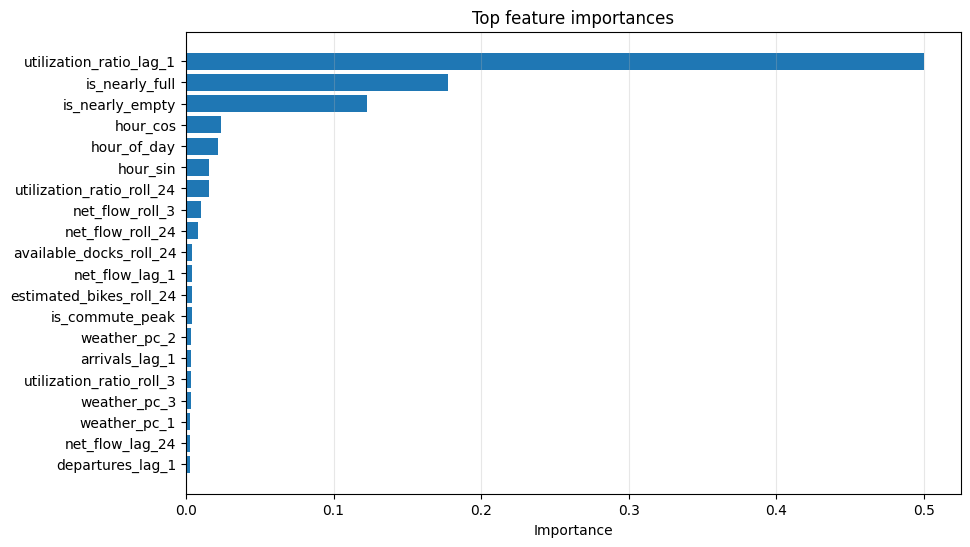

In [12]:

if 'ablation_artifacts' not in globals() or 'ablation_results' not in globals() or ablation_results.empty:
    print('Run the ablation experiment first.')
else:
    best_label = ablation_results.sort_values('r2', ascending=False).iloc[0]['experiment']
    fi = top_feature_importance(ablation_artifacts[best_label]['artifacts'])
    if fi is None:
        print('No feature importance available.')
    else:
        display(Markdown(f'### Top features for: {best_label}'))
        display(fi)
        plot_df = fi.sort_values('importance')
        plt.figure(figsize=(10, 6))
        plt.barh(plot_df['feature'], plot_df['importance'])
        plt.title('Top feature importances')
        plt.xlabel('Importance')
        plt.grid(True, axis='x', alpha=0.3)
        plt.show()



## Optional: save result tables

This writes the experiment summaries to CSV so you can reuse them in the report.


In [13]:

output_dir = globals().get('OUTPUT_DIR')

if SAVE_OUTPUT_TABLES and output_dir is not None:
    saved = []

    objects_to_save = {
        'target_comparison_results.csv': globals().get('target_comparison_results'),
        'topn_results.csv': globals().get('topn_results'),
        'ablation_results.csv': globals().get('ablation_results'),
        'subset_results.csv': globals().get('subset_results'),
        'alert_results.csv': globals().get('alert_results'),
    }

    for filename, obj in objects_to_save.items():
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            out_path = output_dir / filename
            obj.to_csv(out_path, index=False)
            saved.append(str(out_path))

    if saved:
        print('Saved files:')
        for p in saved:
            print(' -', p)
    else:
        print('No non-empty result tables were available to save yet.')
else:
    print('Saving skipped.')


Saved files:
 - outputs/ablation_results.csv
 - outputs/subset_results.csv
 - outputs/alert_results.csv



## How to talk about this notebook in the report

### Main takeaway
The follow-on experiments are no longer centered on raw demand alone. After v7, the stronger project direction is:
- predict **next-hour station utilization**,
- show that **availability-state features** drive the improvement,
- and evaluate **operational threshold alerts** that matter for rebalancing.

### If the results match the expected v7 pattern
You can say:
- `utilization_ratio_next_hour` is more predictable than the older raw-flow targets,
- removing availability-state features causes a clear performance drop,
- restricting to capacity-known rows does not materially change the result,
- and nearly-empty / nearly-full alerts are strong enough to support operational use cases.
